In [13]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    xx = np.array(xx).reshape(nn,1)
    tt = tt.reshape(nn,1)

    return xx, tt

def mi_funcion_cuadrada(vmax = 1, dc = 0, ff = 1, duty = .5, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray] :
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.where(tt % (1/ff) < (1/ff) * duty, 1, -1)
    xx = vmax * xx + dc
    #signal.square(2* np.pi * ff* tt, duty)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_funcion_triangular(vmax = 1, dc = 0, ff = 1, nn = 1, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop= nn*ts, step=ts)
    T = 1/ff

    xx = [((vmax/T) * (i%T) + dc) for i in tt]
    #signal.sawtooth(2* np.pi * ff* tt, 0.5)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    '''noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
        Generates Gaussian noise, with variance var and zero mean.

        Note: This distribution corresponds to "white noise". (Extracted from ASYS notes, Stochastic process - White Noise)
    '''
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.random.normal(loc=0, scale=np.sqrt(var), size=nn)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_sen_ruidosa( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000, snr = 20) -> tuple[np.ndarray,np.ndarray]:
    xx, tt = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs)
    pot_signal = np.mean(xx**2)
    var_noise = pot_signal / (10**(snr/10))  # Calculando potencia de señal conocida "senoidal"
    # var_noise = power(xx) / (10**(snr/10))    # Lo mismo, calculando potencia por definicion
    
    noise, _ = noise_generator(var_noise, nn, fs)
    xx = xx + noise

    return xx, tt

def power(x: np.ndarray) -> float:
    return np.mean(np.abs(x)**2)

def snr(signal: np.ndarray, noise: np.ndarray) -> float:
    return 10 * np.log10(np.mean(signal**2) / np.mean(noise**2))

def mi_adc(xx, Vfs, bits=4):
    '''mi_adc
    Quantizes the signal xx like an ADC with Vfs and bits.
    xx: Signal to be quantized.
    Vfs: ADC [0, Vfs]
    bits: Number of bits of the ADC.
    ''' 
    q = Vfs/(2**bits) 
    xq = np.round(xx/q) * q
    vmax =  q*(2**(bits-1)-1)
    vmin = -q*2**(bits-1)

    np.clip(xq, vmin, vmax, out=xq)
    #xq[xq > vmax] = vmax
    #xq[xq < vmin] = vmin
    return xq

def autocorrelate(xx: np.ndarray) -> np.ndarray:
    xx = np.asarray(xx).flatten()

    autocorr = np.correlate(xx, xx, mode='full')/xx.size        # Normalizated to size. Gives the true values of the autocorrelation
    autocorr = autocorr[autocorr.size//2:]                      # Only keep non negative values
    autocorr = autocorr.reshape(-1,1)                           # Reshape to column vector (standard of PDS)
    return autocorr

def mod_db(xx: np.ndarray) -> np.ndarray:
    return 20*np.log10(np.abs(xx))

def mod_dbw(xx: np.ndarray) -> np.ndarray:
    return 10*np.log10(np.abs(xx))

def freq_axis(xx: np.ndarray, fs: float) -> np.ndarray:
    '''freq_axis
    
    Equal to np.fft.fftfreq. It generates the correct freq axis for the fft algorithm.
    Axis has the form:
    [0, △f, 2△f, ..., fs/2, -fs/2, -(fs/2-△f), ..., -△f]
    Note: the positive half always starts with 0. The negative half always starts with -fs/2, so, the negative half has one extra value if the length of the signal is even.
    xx: signal to generate the axis for. Only the length is used.
    fs: sampling frequency
    '''
    nn = xx.shape[0]
    half = np.arange(0, fs/2, fs/nn)
    ff = np.concatenate((half, -half[::-1] - fs/nn))
    ff = ff[:nn]
    return ff.reshape(-1,1)

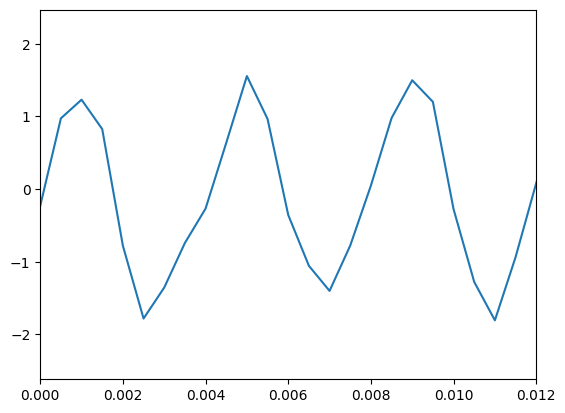

Potencia de la señal: [0.98764789]
Potencia del ruido: [0.10028713]
Potencia del ruido: [0.10028713]
SNR: [9.93356957] dB


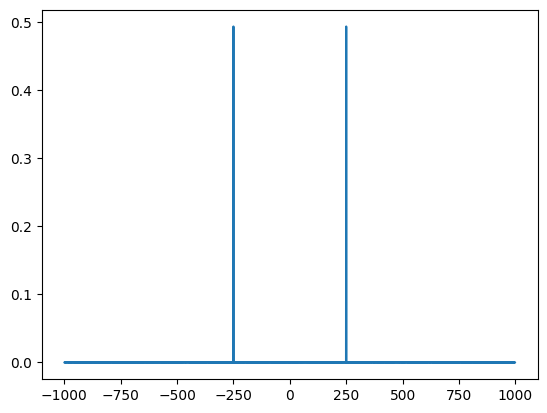

In [14]:
fs = 2000
N = 2000
delta_f = fs/N

vmax = 2**.5
ff = fs/8
snr = 10

xx, tt = mi_sen_ruidosa(vmax=vmax, dc=0, ff=ff, nn=N, fs=fs, snr=snr)

plt.plot(tt, xx)
plt.xlim(0, 3/ff)
plt.show()

fft = np.fft.fft(xx, axis=0)/N
abs_xx_fft = np.abs(fft)
PX = abs_xx_fft**2
plt.plot(freq_axis(xx, fs), PX)

P_signal = 2*PX[int(ff)]
print(f"Potencia de la señal: {P_signal}")

P_noise = np.sum(PX) - P_signal
print(f"Potencia del ruido: {P_noise}")
P_noise = power(xx) - P_signal
print(f"Potencia del ruido: {P_noise}")


print(f"SNR: {10 * np.log10(P_signal / P_noise)} dB")

pot = np.mean(xx**2)

C:\Users\Agustin\AppData\Local\Temp\ipykernel_5504\426076096.py:13: RuntimeWarning: divide by zero encountered in log10
  fft_window_db = 20*np.log10(np.abs(fft_window))


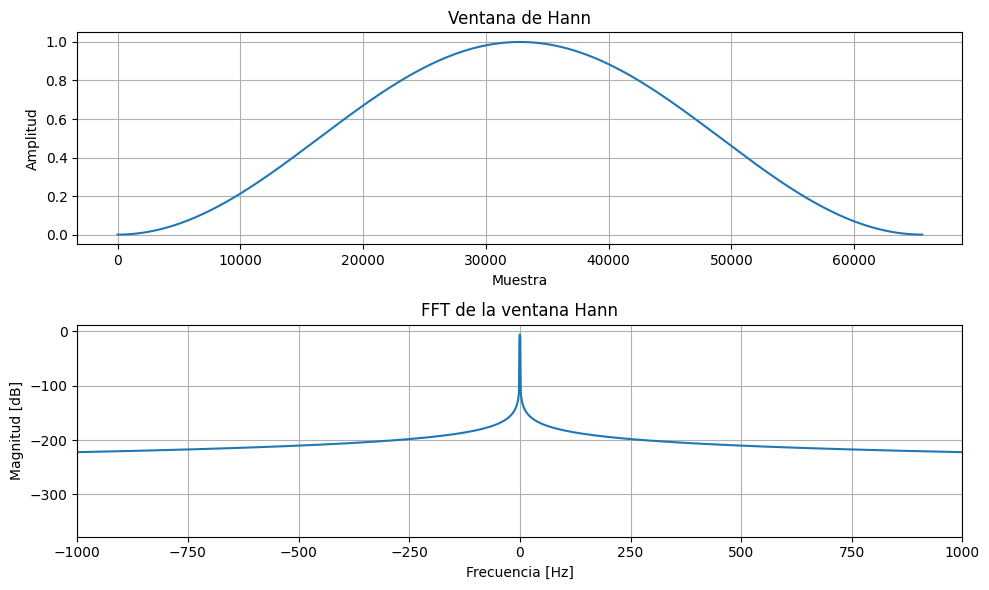

In [30]:
import scipy.signal as signal

N = 65536
fs = N
delta_f = fs/N

##### Aplicacion de ventana
window = signal.windows.hann(N)

fft_window = np.fft.fft(window, n=N)/N
fft_window = np.fft.fftshift(fft_window)

fft_window_db = 20*np.log10(np.abs(fft_window))
##### Eje frecuencia
ff = np.arange(-N//2, N//2) * delta_f

##################################################
# Gráfico
##################################################

plt.figure(figsize=(10,6))

plt.subplot(2,1,1)

plt.plot(window)

plt.title("Ventana de Hann")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")

plt.grid()

##################################################

plt.subplot(2,1,2)

plt.plot(ff, fft_window_db)

plt.xlim(-1000, 1000)
#plt.ylim(-120, 5)
#plt.ylim(0,0.03)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")

plt.title("FFT de la ventana Hann")

plt.grid()

plt.tight_layout()
plt.show()